# Gas Turbine Drivers for Compressors

This notebook demonstrates the three ways NeqSim couples **gas-turbine power** to
**compressor shaft demand**, using the classes in
`neqsim.process.equipment.powergeneration` and
`neqsim.process.equipment.compressor.driver`.

| Part | What it shows | Key classes |
|------|---------------|-------------|
| **A** | Brayton-cycle thermo model that burns fuel and produces shaft power | `GasTurbine` |
| **B** | Catalog turbine that caps a compressor train (`setEnforcePowerLimit`) | `GasTurbineUnit`, `GasTurbineCatalog` |
| **C** | Ambient-derated driver curve feeding `Compressor.getCapacityMax()` | `GasTurbineDriver`, `Compressor` |

All numbers are illustrative.

## 0 — Start NeqSim from the workspace classpath

In [1]:
import os, sys
from pathlib import Path

here = Path.cwd().resolve()
for candidate in [here] + list(here.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate NeqSim project root.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)
print("NeqSim JVM ready — classes loaded from", PROJECT_ROOT / "target" / "classes")

All NeqSim classes imported OK
NeqSim JVM ready — classes loaded from C:\Users\ESOL\Documents\GitHub\neqsim\target\classes


In [2]:
import jpype
import numpy as np
import matplotlib.pyplot as plt

SystemSrkEos  = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
Stream        = jpype.JClass("neqsim.process.equipment.stream.Stream")
Compressor    = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler        = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
UUID          = jpype.JClass("java.util.UUID")

GasTurbine        = jpype.JClass("neqsim.process.equipment.powergeneration.GasTurbine")
pkg               = "neqsim.process.equipment.powergeneration.gasturbine"
GasTurbineCatalog = jpype.JClass(pkg + ".GasTurbineCatalog")
GasTurbineUnit    = jpype.JClass(pkg + ".GasTurbineUnit")
GasTurbineDriver  = jpype.JClass("neqsim.process.equipment.compressor.driver.GasTurbineDriver")
print("Imports OK")

Imports OK


## Part A — `GasTurbine`: a Brayton-cycle thermo model

`GasTurbine` is a self-contained simple-cycle model: an internal air compressor,
a combustor that burns the incoming fuel gas, and an expander. It sizes the
combustion air from the stoichiometric oxygen demand times an **excess-air
factor** (default 2.5) so the post-combustion flash stays physical.

work overtakes the expander recovery in this simplified balance.

This is a *simplified low-pressure-ratio* teaching model. The net shaft power ispressure modest (a few bara) — at high pressure ratios the cold air-compression

the expander work minus the air-compressor work, and most of the fuel energysteam cycle would recover in a combined-cycle plant. Keep the combustion
leaves as hot exhaust (`getHeat()`), which is exactly what a HRSG / bottoming

In [3]:
def build_fuel_stream(flow_kg_per_hr=4000.0):
    fuel = SystemSrkEos(273.15 + 25.0, 25.0)
    fuel.addComponent("methane", 0.90)
    fuel.addComponent("ethane",  0.06)
    fuel.addComponent("propane", 0.02)
    fuel.addComponent("nitrogen", 0.02)
    fuel.setMixingRule("classic")
    s = Stream("fuel gas", fuel)
    s.setFlowRate(flow_kg_per_hr, "kg/hr")
    s.setTemperature(273.15 + 25.0, "K")
    s.setPressure(25.0, "bara")
    s.run()
    return s

fuelStream = build_fuel_stream()
gt = GasTurbine("GT-A", fuelStream)
gt.combustionpressure = 2.5        # bara (public field) - simplified low-pressure cycle
gt.setExcessAirFactor(2.5)
gt.run()

print(f"Net shaft power   : {gt.getPower('MW'):8.3f} MW")
print(f"Heat output       : {gt.getHeat() / 1e6:8.3f} MW")
print(f"Ideal air/fuel    : {gt.calcIdealAirFuelRatio():8.3f}")

Net shaft power   :    0.583 MW
Heat output       :   31.632 MW
Ideal air/fuel    :   16.379


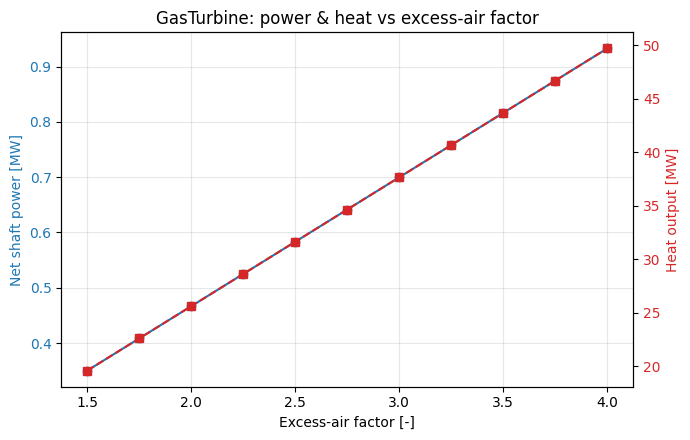

In [4]:
# Sweep the excess-air factor and watch power / heat respond
eaf_values = np.linspace(1.5, 4.0, 11)
powers, heats = [], []
for eaf in eaf_values:
    s = build_fuel_stream()
    g = GasTurbine("GT-sweep", s)
    g.combustionpressure = 2.5
    g.setExcessAirFactor(float(eaf))
    g.run()
    powers.append(g.getPower("MW"))
    heats.append(g.getHeat() / 1e6)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(eaf_values, powers, "o-", color="tab:blue", label="Net shaft power")
ax1.set_xlabel("Excess-air factor [-]")
ax1.set_ylabel("Net shaft power [MW]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(eaf_values, heats, "s--", color="tab:red", label="Heat output")
ax2.set_ylabel("Heat output [MW]", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("GasTurbine: power & heat vs excess-air factor")
fig.tight_layout()
plt.show()

**Discussion.** More excess air dilutes the combustion products and shifts the
air-compressor / expander balance, so net shaft power and heat output both move
with the excess-air factor. The default of 2.5 keeps oxygen well above the
stoichiometric demand for the hydrocarbons in the fuel, which is why `run()`
returns finite, positive power rather than failing on an oxygen-depleted flash.

In this simplified cycle the shaft power is modest and most of the fuel energyshows up as exhaust heat — the quantity a combined-cycle HRSG would harvest.

## Part B — `GasTurbineUnit`: capping a compressor train

`GasTurbineUnit` is a catalog-driven *energy-accounting* wrapper. It reads the
live shaft power of any `Compressor` added with `addPowerConsumer(...)`. With
`setEnforcePowerLimit(true)` it also **feeds its site-corrected available power
back** to the compressors as a driver curve, so the turbine becomes a hard
ceiling for the train.

Because it is an accounting wrapper, the cleanest pattern is to solve the
process flowsheet first (so the compressor shaft power is known), then run the
`GasTurbineUnit` on its own with `run(UUID.randomUUID())`. Keeping it out of the
`ProcessSystem` avoids re-running the compressor while the unit re-installs
driver curves.

In [5]:
def build_train(feed_kg_per_hr, suction_bara=40.0, discharge_bara=160.0):
    """Solve a single-stage export compression flowsheet and return (proc, comp)."""
    fluid = SystemSrkEos(273.15 + 25.0, suction_bara)
    fluid.addComponent("methane", 0.85)
    fluid.addComponent("ethane",  0.08)
    fluid.addComponent("propane", 0.04)
    fluid.addComponent("CO2",     0.02)
    fluid.addComponent("nitrogen", 0.01)
    fluid.setMixingRule("classic")
    feed = Stream("feed gas", fluid)
    feed.setTemperature(273.15 + 25.0, "K")
    feed.setPressure(suction_bara, "bara")
    feed.setFlowRate(feed_kg_per_hr, "kg/hr")
    comp = Compressor("export compressor", feed)
    comp.setOutletPressure(discharge_bara, "bara")
    comp.setIsentropicEfficiency(0.78)
    cooler = Cooler("after-cooler", comp.getOutletStream())
    cooler.setOutTemperature(273.15 + 40.0)
    proc = ProcessSystem()
    proc.add(feed)
    proc.add(comp)
    proc.add(cooler)
    proc.run()
    return proc, comp

# 1) Solve the compression train so the shaft power is known
proc, comp = build_train(280000.0)

# 2) Attach a catalog turbine as an accounting wrapper and run it standalone
gtu = GasTurbineUnit("GT-A", build_fuel_stream(), GasTurbineCatalog.get("LM2500"))
gtu.addPowerConsumer(comp)
gtu.setEnforcePowerLimit(True)
gtu.run(UUID.randomUUID())

print(f"Compressor shaft power    : {comp.getPower('kW') / 1000.0:7.2f} MW")
print(f"Turbine available power   : {gtu.getAvailablePowerW() / 1e6:7.2f} MW")
print(f"Load fraction             : {gtu.getLoadFraction():7.3f}")
print(f"Overloaded                : {bool(gtu.isOverloaded())}")
print(f"Capacity ceiling (driver) : {comp.getCapacityMax() / 1e6:7.2f} MW")

Compressor shaft power    :   19.70 MW
Turbine available power   :   22.40 MW
Load fraction             :   0.880
Overloaded                : False
Capacity ceiling (driver) :   22.40 MW


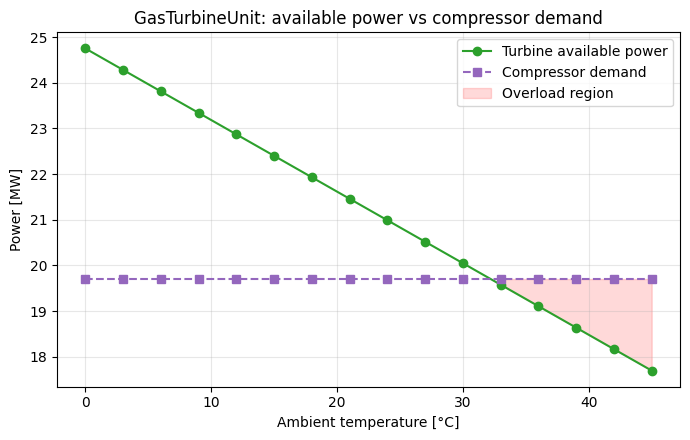

First overload at ambient: 33.0 °C
Power allocation [MW]: {'export compressor': 17.696}
Shortfall at 45 °C: 2.01 MW


In [6]:
# Hot ambient shrinks the available power budget — sweep it and find the overload point.
# The compressor demand is already solved; only the turbine available power changes,
# so we re-run the GasTurbineUnit standalone at each ambient temperature.
ambient_C = np.linspace(0.0, 45.0, 16)
avail_MW, demand_MW, overload = [], [], []
for tC in ambient_C:
    gtu.setAmbientTemperatureK(273.15 + float(tC))
    gtu.run(UUID.randomUUID())
    avail_MW.append(gtu.getAvailablePowerW() / 1e6)
    demand_MW.append(gtu.getDemandedPowerW() / 1e6)
    overload.append(bool(gtu.isOverloaded()))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ambient_C, avail_MW, "o-", color="tab:green", label="Turbine available power")
ax.plot(ambient_C, demand_MW, "s--", color="tab:purple", label="Compressor demand")
ax.fill_between(ambient_C, avail_MW, demand_MW,
                where=np.array(avail_MW) < np.array(demand_MW),
                color="red", alpha=0.15, label="Overload region")
ax.set_xlabel("Ambient temperature [°C]")
ax.set_ylabel("Power [MW]")
ax.set_title("GasTurbineUnit: available power vs compressor demand")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

first_overload = next((t for t, o in zip(ambient_C, overload) if o), None)
print("First overload at ambient:",
      f"{first_overload:.1f} °C" if first_overload is not None else "none in range")
print("Power allocation [MW]:",
      {str(k): round(float(v) / 1e6, 3) for k, v in gtu.getPowerAllocationW().items()})
print(f"Shortfall at {ambient_C[-1]:.0f} °C: {gtu.getPowerShortfallW() / 1e6:.2f} MW")

**Discussion.** The compressor demand is set by the process and is essentially
flat across ambient temperature, while the LM2500's deliverable power falls as
the day heats up. Where the green available-power line drops below the purple
demand line the unit reports `isOverloaded() == True` and a positive
`getPowerShortfallW()`. With `setEnforcePowerLimit(true)` each driven
compressor also receives its share of the available power as a driver curve, so
downstream capacity / bottleneck analysis sees the same ceiling — visible above
as the `getCapacityMax()` value that tracks the available power.

## Part C — `GasTurbineDriver`: a derated driver curve on a compressor

A `Compressor` can be given a `GasTurbineDriver` directly via `setDriverCurve`.
The driver applies ambient/altitude derating and feeds the resulting available
power into `Compressor.getCapacityMax()` (highest priority in the capacity
resolution order), evaluated at the driver's rated speed.

In [7]:
fluid = SystemSrkEos(273.15 + 25.0, 40.0)
fluid.addComponent("methane", 0.85)
fluid.addComponent("ethane",  0.10)
fluid.addComponent("propane", 0.05)
fluid.setMixingRule("classic")
suction = Stream("suction", fluid)
suction.setFlowRate(150000.0, "kg/hr")
suction.setTemperature(273.15 + 25.0, "K")
suction.setPressure(40.0, "bara")
suction.run()

comp2 = Compressor("driven compressor", suction)
comp2.setOutletPressure(120.0, "bara")
comp2.setIsentropicEfficiency(0.78)

driver = GasTurbineDriver(22000.0, 0.35)   # 22 MW rated, 35% design efficiency
comp2.setDriverCurve(driver)
comp2.run()

print(f"Compressor shaft power : {comp2.getPower('kW') / 1000.0:7.2f} MW")
print(f"Driver rated speed     : {driver.getRatedSpeed():7.0f} rpm")
print(f"getCapacityMax()       : {comp2.getCapacityMax() / 1e6:7.2f} MW")
print(f"Can supply demand?     : {bool(driver.canSupplyPower(comp2.getPower('kW'), driver.getRatedSpeed()))}")

Compressor shaft power :    7.99 MW
Driver rated speed     :    7500 rpm
getCapacityMax()       :   22.00 MW
Can supply demand?     : True


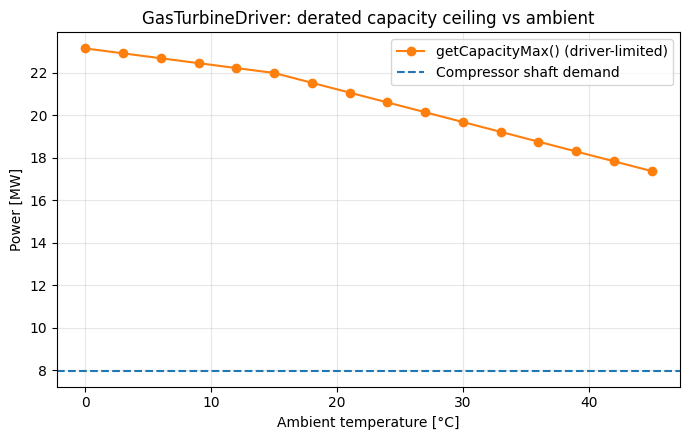

In [8]:
# Ambient derating of the driver curve → shrinking compressor capacity ceiling
ambient_C = np.linspace(0.0, 45.0, 16)
cap_MW = []
shaft_MW = comp2.getPower("kW") / 1000.0
for tC in ambient_C:
    driver.setAmbientTemperature(float(tC))
    cap_MW.append(comp2.getCapacityMax() / 1e6)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ambient_C, cap_MW, "o-", color="tab:orange", label="getCapacityMax() (driver-limited)")
ax.axhline(shaft_MW, color="tab:blue", linestyle="--", label="Compressor shaft demand")
ax.set_xlabel("Ambient temperature [°C]")
ax.set_ylabel("Power [MW]")
ax.set_title("GasTurbineDriver: derated capacity ceiling vs ambient")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Discussion.** The orange curve is the compressor's maximum deliverable power
as governed by its gas-turbine driver, which derates with rising ambient
temperature. As long as it stays above the dashed shaft-demand line the
compressor can be driven; where it crosses, the machine is driver-limited.
This is the same `DriverCurve` mechanism that `GasTurbineUnit` installs when
`enforcePowerLimit` is enabled.

### Summary

- **`GasTurbine`** — full Brayton thermo model; use when you need combustion
  products, heat, and HRSG integration.
- **`GasTurbineUnit`** — catalog accounting + optional power-limit feedback;
  use for fleet sizing, dispatch, and capping a compression train.
- **`GasTurbineDriver`** (a `DriverCurve`) — ambient-derated available power
  that feeds `Compressor.getCapacityMax()` for capacity / bottleneck analysis.